# Money Market Rates


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


FILEDATA = 'ref_rates.xlsx'

# Data

Use the data in `data/ref_rates.xlsx` to explore several key money-market rates.
* SOFR
* Fed funds
* 3-month T-bill yield

***

# 1. Exploring Money-Market Rates

### 1.
Plot the time series.

### 2.
Calculate the correlation between the three rates (filtering to the dates for which they all have reported values.)

Do this correlation analysis for the data in
* levels (as provided)
* differences (day-over-day changes)

### 3.

Estimate an autoregression for SOFR:

$$r_{t} = \alpha + \beta\, r_{t-1} + \epsilon_{t}$$

Report the estimated regression beta and r-squared.

Comment on what this regression tells us about the nature of interest rates. 
* That is, can we forecast the next period's rate? 
* Does the series have **autocorrelation**?

### 4.

Estimate an autoregression for returns of the S&P 500 ETF, `SPY`, rather than using SOFR. Get data from 
* `data/spy_data_daily.xlsx`

Are SPY returns autocorrelated? And SPY prices?

In [27]:
data = pd.read_excel(FILEDATA, sheet_name='data')
print(data)

           date  DTB3   DFF  SOFR
0    2018-01-01   NaN  1.33   NaN
1    2018-01-02  1.42  1.42   NaN
2    2018-01-03  1.39  1.42   NaN
3    2018-01-04  1.39  1.42   NaN
4    2018-01-05  1.37  1.42   NaN
...         ...   ...   ...   ...
3073 2026-06-01  3.63  3.62  3.65
3074 2026-06-02  3.63  3.62  3.63
3075 2026-06-03  3.63  3.62  3.61
3076 2026-06-04  3.63  3.62  3.62
3077 2026-06-05   NaN   NaN  3.63

[3078 rows x 4 columns]


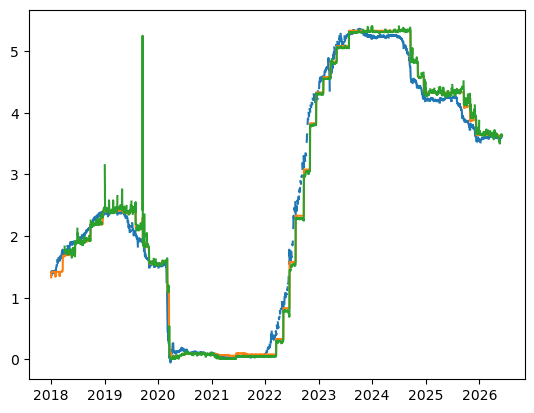

In [41]:
# Plotting the time series
plt.plot(data['date'], data['DTB3'])
plt.plot(data['date'], data['DFF'])
plt.plot(data['date'], data['SOFR'])
plt.show()

In [61]:
# Filtering data for dates where they all have reported value
data_clean = data.dropna()
data_clean = data_clean.drop(columns=['date'])
print(data_clean)

      DTB3   DFF  SOFR
92    1.72  1.69  1.83
93    1.68  1.69  1.74
94    1.69  1.69  1.75
95    1.70  1.69  1.75
98    1.73  1.69  1.75
...    ...   ...   ...
3070  3.60  3.62  3.63
3073  3.63  3.62  3.65
3074  3.63  3.62  3.63
3075  3.63  3.62  3.61
3076  3.63  3.62  3.62

[2041 rows x 3 columns]


In [63]:
# Levels correlation using cleaned data
levels_corr = data_clean.corr()
print(levels_corr)

          DTB3       DFF      SOFR
DTB3  1.000000  0.994704  0.992898
DFF   0.994704  1.000000  0.999091
SOFR  0.992898  0.999091  1.000000


In [69]:
# Correlation using day to day differences
data_differences = data.diff()
data_differences = data_differences.dropna()
data_differences = data_differences.drop(columns=['date'])
data_differences_corr = data_differences.corr()
print(data_differences_corr)

          DTB3       DFF      SOFR
DTB3  1.000000  0.007996  0.037454
DFF   0.007996  1.000000  0.496540
SOFR  0.037454  0.496540  1.000000


In [79]:
from sklearn.linear_model import LinearRegression

In [81]:
# Building regression variables
data['SOFR_lag']=data['SOFR'].shift(1)
reg_data = data[['SOFR','SOFR_lag']].dropna()
reg_data.head()
X = reg_data[['SOFR_lag']]
Y = reg_data['SOFR']

# Regression
model = LinearRegression()
model.fit(X, Y)
beta = model.coef_[0]
alpha = model.intercept_
r_squared = model.score(X, Y)
print("Beta:", beta)
print("Alpha:", alpha)
print("R-squared:", r_squared)

Beta: 0.9985176516788362
Alpha: 0.0048023387477540425
R-squared: 0.9970022295316878


In [ ]:
# Interpreting regression results 
# We can see taht the beta for the regression is very high (0.9985) which means that the day to day
# movement of SOFR is very minimal.
# The alpha is very close to zero which in conjunction with beta being very high tells us that the SOFR 
# movement is similar to a random walk: tomorrow's forecast is roughly yesterday's rate with a small drift.
# The R-squared tells us that essentially, we can be confident in predicting the next day's SOFR rate. 
# This specifically happens because the SOFR rate has a strong autocorrelation since today's value is strongly 
# tied to yesterday's value.  

In [101]:
# Building regression variables for SPY
File_Data = 'spy_data_daily.xlsx'
spy_data_returns = pd.read_excel(File_Data, sheet_name="total returns")
spy_data_returns = spy_data_returns.drop(columns=['date', '^IRX'])
spy_data_returns['returns_lag'] = spy_data_returns['SPY'].shift(1)
spy_data_returns = spy_data_returns.dropna()
spy_data_returns.head()
A = spy_data_returns[['returns_lag']]
B = spy_data_returns['SPY']

# Regression
spy_model = LinearRegression()
spy_model.fit(A, B)
spy_beta = spy_model.coef_[0]
spy_alpha = spy_model.intercept_
spy_r_squared = spy_model.score(A, B)
print("Beta:", spy_beta)
print("Alpha:", spy_alpha)
print("R-squared", spy_r_squared)

Beta: -0.08287689162977581
Alpha: 0.0005187528909357594
R-squared 0.00686850910591652


In [ ]:
# Interpreting regression results #
# This time the beta is negative and very small, which tells us that yesterday's returns 
# have very little linear influence on today's return.  
# The alpha is also very small and tells us the average daily return is small but positive for SPY.  
# The R-squared being small also tells us that less that 1% of the variation is explained by our regression,
# so SPY returns are very ewakly autocorrelated.  

In [103]:
# Doing same regression on SPY but this time with prices instead of returns
spy_data_prices = pd.read_excel(File_Data, sheet_name="prices")
spy_data_prices = spy_data_prices.drop(columns=['date', '^IRX'])
spy_data_prices['SPY_lag'] = spy_data_prices['SPY'].shift(1)
spy_data_prices = spy_data_prices.dropna()

A_prices = spy_data_prices[['SPY_lag']]
B_prices = spy_data_prices['SPY']

spy_price_model = LinearRegression()
spy_price_model.fit(A_prices, B_prices)

spy_price_beta = spy_price_model.coef_[0]
spy_price_alpha = spy_price_model.intercept_
spy_price_r_squared = spy_price_model.score(A_prices, B_prices)

print("Beta:", spy_price_beta)
print("Alpha:", spy_price_alpha)
print("R-squared:", spy_price_r_squared)

Beta: 1.000589789825372
Alpha: -0.01615836685920158
R-squared: 0.999759882485025


In [ ]:
# Here we see pretty much the opposite, a very high R-squared value tells us that SPY prices are
# very autocorrelated: today = yesterday + some drift.  